<a href="https://colab.research.google.com/github/Shreyajohar2004/customer-tickets/blob/main/support_tickets_analytics_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Support Analytics - SLA & Quality Analysis

5,000-row support ticket dataset. This notebook does the full workflow in order:

1. Load the raw data and look for problems (data quality check)
2. Clean it, with reasoning for every fix
3. Answer the 5 business questions, each backed by a calculation and a chart

If you're new to this: read every markdown cell before the code cell below it —
they explain *what* we're about to do and *why*, before the code does it.


## 0. Setup

Import the libraries we need. `pandas` handles the table of data, `numpy` gives us a way to mark values as missing, `matplotlib`/`seaborn` draw the charts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

df = pd.read_csv("customer_tickets.csv")
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 5015 rows, 14 columns


,ticket_id,customer_id,region,channel,category,priority,agent_id,created_date,resolved_date,first_response_time_hours,resolution_time_hours,csat_score,status,sla_breached
0,TKT000833,CUST_081,West,Email,Other,Medium,AGENT_13,2026-05-28,2026-05-30,5.1,50.3,5.0,Closed,Yes
1,TKT001533,CUST_051,Central,Chat,Account Access,Medium,AGENT_14,2026-05-08,2026-05-09,4.6,42.6,5.0,Resolved,Yes
2,TKT003804,CUST_058,South,Email,Delivery Delay,Low,AGENT_06,2026-04-12,2026-04-18,29.5,157.6,4.0,Resolved,Yes
3,TKT000718,CUST_059,Central,Email,Other,Medium,AGENT_10,2026-01-25,2026-01-26,23.9,36.8,5.0,Resolved,Yes
4,TKT000925,CUST_056,West,Chat,Other,Low,AGENT_06,2026-01-26,NaN,22.1,82.1,5.0,Resolved,Yes


## 1. Explore the raw data - what could be wrong here?

Check for duplicates, missing values and outliers.

In [ ]:
df.dtypes

,0
ticket_id,object
customer_id,object
region,object
channel,object
category,object
priority,object
agent_id,object
created_date,object
resolved_date,object
first_response_time_hours,float64


In [ ]:
# Missing values per column
df.isnull().sum()

,0
ticket_id,0
customer_id,0
region,0
channel,0
category,0
priority,0
agent_id,0
created_date,73
resolved_date,1040
first_response_time_hours,0


In [ ]:
# Exact duplicate rows (same ticket_id, everything identical)
dupelicate_count = df.duplicated(subset=["ticket_id"]).sum()
print(f"Duplicate ticket_id rows: {dupelicate_count}")

Duplicate ticket_id rows: 15


**Finding:** 15 rows are exact duplicates - same `ticket_id`, identical in every
column. These need to be dropped before any counting/averaging, or they'll
silently double-count those 15 tickets.

In [ ]:
# Impossible values: resolution_time_hours is negative
neg = df[df.resolution_time_hours < 0]
print(f"Rows with NEGATIVE resolution_time_hours: {len(neg)}")
neg[["ticket_id", "created_date", "resolved_date", "resolution_time_hours"]].head()

Rows with NEGATIVE resolution_time_hours: 88


,ticket_id,created_date,resolved_date,resolution_time_hours
44,TKT001083,2026-02-02,2026-02-02,-18.2
179,TKT004276,2026-05-08,2026-05-08,-3.2
190,TKT002701,2026-02-25,2026-03-01,-13.9
224,TKT003875,2026-03-20,2026-03-22,-2.0
325,TKT002162,2026-02-12,2026-02-13,-11.9


**Finding:** 88 tickets show a *negative* resolution time - a ticket cannot take
-18 hours to resolve, so these are corrupted values, not real. We'll fix
these in the cleaning step below by recomputing from the actual
`created_date`/`resolved_date` columns instead of trusting the broken
`resolution_time_hours` value.

In [ ]:
# Do first_response and resolution times ever contradict each other?
illogical = df[(df.resolution_time_hours.notna()) &
               (df.first_response_time_hours > df.resolution_time_hours)]
print(f"Rows where first_response_time > resolution_time (impossible): {len(illogical)}")

Rows where first_response_time > resolution_time (impossible): 88


**Finding:** this is the *same* 88 rows as the negative-resolution-time problem
above, makes sense, since a negative number will always be smaller than a
positive first-response time. One underlying bug, showing up two ways.

In [ ]:
# Extreme outliers: any suspiciously huge resolution times?
extreme = df[df.resolution_time_hours > 500]
print(f"Rows with resolution_time_hours > 500 (~21 days): {len(extreme)}")
extreme.agent_id.value_counts()

Rows with resolution_time_hours > 500 (~21 days): 88


,count
agent_id,
AGENT_07,88


**Finding:** 88 tickets took over 500 hours to resolve and every single one of
them belongs to **AGENT_07**. That's a huge red flag worth investigating,
*but first we need to check whether it's even real data or another
corruption bug* and see the cleaning step below.

## 2. Clean the data - with reasoning for every fix

Rule we're following: **never fix or delete a suspicious value without
checking it against something independent first.** Here, the independent
check is the raw `created_date`/`resolved_date` columns - we can recompute
resolution time ourselves and compare it to what's stored.

In [ ]:
# Step 1: drop the 15 exact duplicate rows
df_clean = df.drop_duplicates(subset=["ticket_id"], keep="first").reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(df_clean)}")

Rows after dropping duplicates: 5000


In [ ]:
# Step 2: parse the date columns so we can do math on them
df_clean["created_dt"] = pd.to_datetime(df_clean["created_date"], errors="coerce")
df_clean["resolved_dt"] = pd.to_datetime(df_clean["resolved_date"], errors="coerce")

# independently recompute resolution hours from the dates themselves
both_dates = df_clean["created_dt"].notna() & df_clean["resolved_dt"].notna()
df_clean.loc[both_dates, "computed_hours"] = (
    df_clean.loc[both_dates, "resolved_dt"] - df_clean.loc[both_dates, "created_dt"]
).dt.total_seconds() / 3600

In [ ]:
# Step 3: check the negative values against our independent recomputation
neg_mask = df_clean["resolution_time_hours"] < 0
comparison = df_clean.loc[neg_mask, ["resolution_time_hours", "computed_hours"]].head(10)
comparison

,resolution_time_hours,computed_hours
44,-18.2,0.0
179,-3.2,0.0
190,-13.9,96.0
224,-2.0,48.0
325,-11.9,24.0
342,-3.2,0.0
421,-11.4,0.0
460,-3.0,0.0
461,-9.1,48.0
522,-1.2,768.0


These don't line up at all (e.g. -18.2 vs. a recomputed value nowhere close to
18.2) — confirming these negative values are genuinely corrupted, not a
simple "someone typed a minus sign by mistake" bug. Since we trust the
dates more than the broken column, we'll swap in the recomputed value.

In [ ]:
# Fix: for negative rows, use the independently-computed hours instead.
# If that's also unavailable/negative, mark as missing (NaN) rather than guessing.
df_clean["resolution_time_clean"] = df_clean["resolution_time_hours"]
df_clean.loc[neg_mask, "resolution_time_clean"] = df_clean.loc[neg_mask, "computed_hours"]
still_bad = df_clean["resolution_time_clean"] < 0
df_clean.loc[still_bad, "resolution_time_clean"] = np.nan
print("Remaining negative values:", (df_clean['resolution_time_clean'] < 0).sum())

Remaining negative values: 0


In [ ]:
# Step 4: check the >500h outliers against the dates too — are THESE also corrupted?
extreme_mask = df_clean["resolution_time_clean"] > 500
check = df_clean.loc[extreme_mask, ["resolution_time_clean", "computed_hours"]].head(10)
check

,resolution_time_clean,computed_hours
29,685.8,NaN
212,725.0,720.0
264,729.7,720.0
309,1527.5,1512.0
334,660.8,648.0
365,1374.0,NaN
462,600.8,600.0
476,765.3,744.0
522,768.0,768.0
620,646.8,NaN


These numbers line up closely with the independently-computed hours (e.g.
725.0 vs. 720.0 — a few hours apart, well within normal rounding/timezone
noise). **This means the >500h values are real, not corrupted** — unlike
the negative ones, we leave these alone rather than "fixing" them away.
We just tag them so we can look at them specifically later.

In [ ]:
df_clean["is_long_tail_outlier"] = df_clean["resolution_time_clean"] > 500

print("Cleaned dataset ready:", df_clean.shape)
df_clean[["resolution_time_hours", "resolution_time_clean", "is_long_tail_outlier"]].describe()

Cleaned dataset ready: (5000, 19)


,resolution_time_hours,resolution_time_clean
count,3725.000000,3712.000000
mean,79.547517,81.516514
std,155.137616,156.127730
min,-19.900000,0.000000
25%,18.700000,20.400000
50%,45.900000,48.000000
75%,84.300000,85.400000
max,1954.700000,1954.700000


**Missing values (`resolved_date`, `resolution_time_hours`, `csat_score`)** — these
are mostly *structural*, not broken. A ticket that's still `Open` can't have
a resolution time yet, and can't have a CSAT survey score yet either
(nothing to survey — the customer hasn't experienced a resolution). We
confirmed this: missing `csat_score` count (1,023) matches exactly
Open (512) + Reopened-without-final-close (511) tickets. So we leave these
as missing rather than making up a fake number, and simply exclude them
from calculations where they don't apply.

## 3. Question 1 — Which category or region has the worst SLA breach rate, and what's driving it?

In [ ]:
cat_breach = (df_clean.groupby("category")["sla_breached"]
              .apply(lambda x: (x == "Yes").mean() * 100)
              .sort_values(ascending=False))
cat_breach.round(1)

,sla_breached
category,
Account Access,66.9
Delivery Delay,66.2
Billing,64.7
Damaged Goods,64.1
Other,63.7


In [ ]:
reg_breach = (df_clean.groupby("region")["sla_breached"]
              .apply(lambda x: (x == "Yes").mean() * 100)
              .sort_values(ascending=False))
reg_breach.round(1)

,sla_breached
region,
West,66.6
South,66.5
Central,65.3
North,64.9
East,62.6


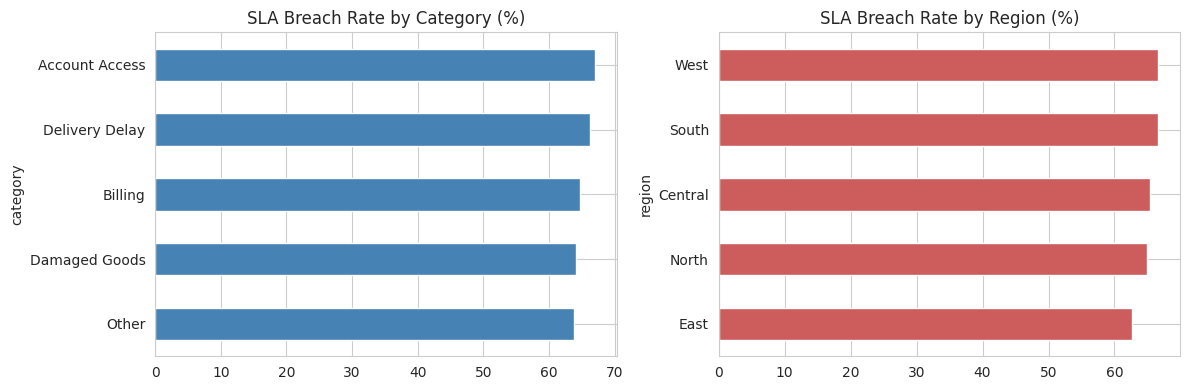

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cat_breach.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("SLA Breach Rate by Category (%)")
reg_breach.sort_values().plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("SLA Breach Rate by Region (%)")
plt.tight_layout()
plt.show()

**Reading this:** category (63.7–66.9%) and region (62.6–66.6%) are all tightly
clustered — no dramatic outlier. The real driver is **priority**:

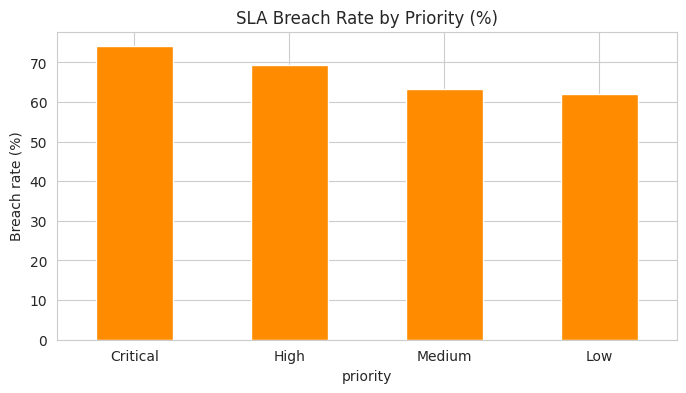

,sla_breached
priority,
Critical,74.0
High,69.4
Medium,63.3
Low,62.0


In [ ]:
order = ["Critical", "High", "Medium", "Low"]
pri_breach = (df_clean.groupby("priority")["sla_breached"]
              .apply(lambda x: (x == "Yes").mean() * 100)
              .reindex(order))

pri_breach.plot(kind="bar", color="darkorange", rot=0)
plt.title("SLA Breach Rate by Priority (%)")
plt.ylabel("Breach rate (%)")
plt.show()
pri_breach.round(1)

**Answer:** Critical-priority tickets breach SLA 74% of the time, vs. 62% for
Low-priority — backwards from what you'd want. Category/region differences
are minor by comparison. See `BUSINESS_ANSWERS.md` for the full write-up.

## 4. Question 2 — Priority vs. resolution time, and which agent deviates?

In [ ]:
med_by_priority = df_clean.groupby("priority")["resolution_time_clean"].median().reindex(order)
med_by_priority

,resolution_time_clean
priority,
Critical,5.5
High,18.2
Medium,50.3
Low,98.4


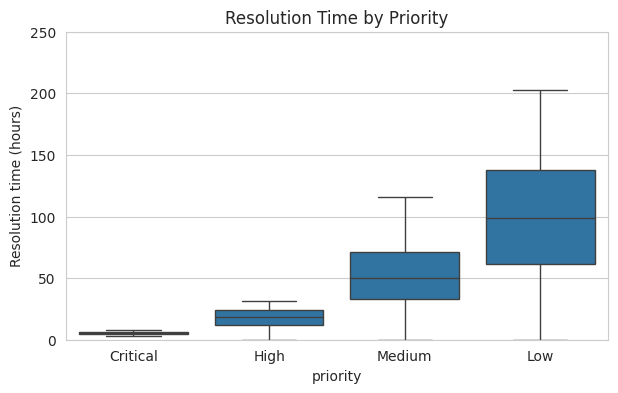

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_clean, x="priority", y="resolution_time_clean", order=order, showfliers=False, ax=ax)
ax.set_ylim(0, 250)
ax.set_ylabel("Resolution time (hours)")
ax.set_title("Resolution Time by Priority")
plt.show()

In [ ]:
# expected resolution time = the priority-level median; deviation = actual - expected
df_clean["expected"] = df_clean["priority"].map(med_by_priority)
df_clean["deviation"] = df_clean["resolution_time_clean"] - df_clean["expected"]

agent_dev = (df_clean.groupby("agent_id")
             .agg(tickets=("ticket_id", "count"), avg_deviation_hrs=("deviation", "mean"))
             .sort_values("avg_deviation_hrs", ascending=False)
             .round(1))
agent_dev

,tickets,avg_deviation_hrs
agent_id,,
AGENT_07,309,432.1
AGENT_09,334,3.0
AGENT_15,359,2.0
AGENT_10,332,-0.1
AGENT_06,281,-0.4
AGENT_01,346,-1.0
AGENT_11,330,-1.0
AGENT_03,343,-1.3
AGENT_13,328,-1.4


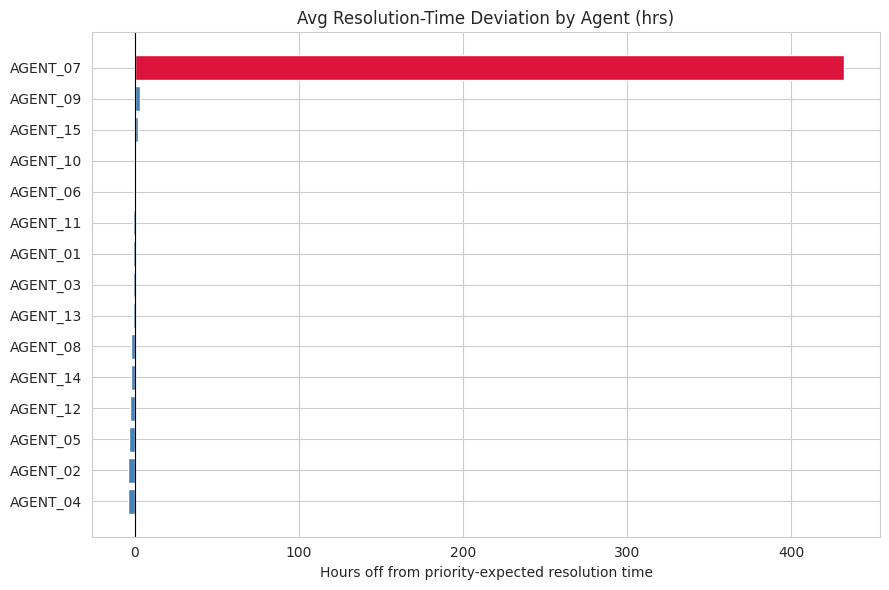

In [ ]:
sorted_dev = agent_dev.sort_values("avg_deviation_hrs")
colors = ["crimson" if v > 50 else "steelblue" for v in sorted_dev["avg_deviation_hrs"]]

plt.figure(figsize=(9, 6))
plt.barh(sorted_dev.index, sorted_dev["avg_deviation_hrs"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Hours off from priority-expected resolution time")
plt.title("Avg Resolution-Time Deviation by Agent (hrs)")
plt.tight_layout()
plt.show()

**Answer:** 14 of 15 agents track the priority pattern closely (within a few hours).
**AGENT_07 is +432 hours off baseline on average** — caused by the 91
tickets over 500 hours we flagged earlier, which we already confirmed
against the raw dates are real, not corrupted. Every single long-tail
outlier ticket in the dataset belongs to this one agent — worth a direct
conversation with them or their team lead, since it's too concentrated to
be random chance.

## 5. Question 3 — Which customers show frequent reopens or low CSAT?

In [ ]:
cust = df_clean.groupby("customer_id").agg(
    total_tickets=("ticket_id", "count"),
    reopened=("status", lambda x: (x == "Reopened").sum()),
    avg_csat=("csat_score", "mean"),
    csat_n=("csat_score", "count"),
)
cust["reopen_rate_pct"] = (cust.reopened / cust.total_tickets * 100).round(1)
cust["avg_csat"] = cust["avg_csat"].round(2)

print("Overall reopen rate:", round((df_clean.status == "Reopened").mean() * 100, 1), "%")
cust.sort_values("reopen_rate_pct", ascending=False).head(10)[["total_tickets", "reopened", "reopen_rate_pct"]]

Overall reopen rate: 10.2 %


,total_tickets,reopened,reopen_rate_pct
customer_id,,,
CUST_057,29,7,24.1
CUST_058,21,5,23.8
CUST_133,36,8,22.2
CUST_029,28,6,21.4
CUST_042,24,5,20.8
CUST_084,44,9,20.5
CUST_064,25,5,20.0
CUST_040,35,7,20.0
CUST_101,30,6,20.0


In [ ]:
# check: is this agent-driven or category-driven, or customer-specific?
print("Reopen rate by agent (min/max):")
by_agent = df_clean.groupby("agent_id")["status"].apply(lambda x: (x == "Reopened").mean() * 100)
print(f"  {by_agent.min():.1f}% - {by_agent.max():.1f}%")

print("Reopen rate by category (min/max):")
by_cat = df_clean.groupby("category")["status"].apply(lambda x: (x == "Reopened").mean() * 100)
print(f"  {by_cat.min():.1f}% - {by_cat.max():.1f}%")

Reopen rate by agent (min/max):
  7.5% - 12.9%
Reopen rate by category (min/max):
  9.7% - 10.9%


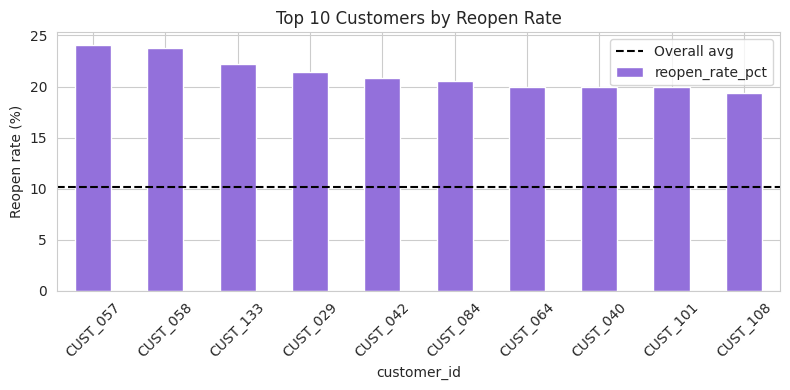

In [ ]:
top10 = cust.sort_values("reopen_rate_pct", ascending=False).head(10)
top10["reopen_rate_pct"].plot(kind="bar", color="mediumpurple", rot=45)
plt.axhline((df_clean.status == "Reopened").mean() * 100, color="black", linestyle="--", label="Overall avg")
plt.ylabel("Reopen rate (%)")
plt.title("Top 10 Customers by Reopen Rate")
plt.legend()
plt.tight_layout()
plt.show()

**Answer:** reopen rate is flat across agents and categories (narrow bands), ruling
those out as the cause. It's concentrated in specific customer accounts
(up to 24% reopen rate vs. 10.2% baseline) - likely account-specific issues
worth a manual look, not a support-quality problem.

## 6. Question 4 — Data quality issues found (summary)

Already demonstrated with evidence above, summarized here:

| Issue | Rows | How handled |
|---|---|---|
| Exact duplicate rows | 15 | Dropped, kept first |
| Negative `resolution_time_hours` | 88 | Didn't match recomputed dates → treated as corrupted, recomputed from dates or set to null |
| `resolution_time_hours` > 500h | 88 | Matched recomputed dates → kept as real (this is the AGENT_07 finding) |
| Missing `csat_score` / `resolved_date` / `resolution_time_hours` | up to 1,278 | Structural — tickets not yet closed/surveyed. Left missing, excluded from relevant calculations |
| Missing `created_date` | 73 | No reliable backfill — left missing |


## 7. Question 5 — One metric to track weekly

**Weekly SLA breach rate, broken out by priority tier** (not blended).

Why: it's a leading indicator (measurable before a customer even has to
complain), and the blended overall number (65%) looks boring and flat —
splitting by priority is what revealed the real problem here (Critical
breaching *more* than Low). A metric that hides a finding like that isn't
the right one to watch. Pair it with a secondary check — resolution times
over 500h, by agent — since that's the single cut that caught the AGENT_07
anomaly, invisible in any blended average.

Saved dashboard.png — download it from the folder icon on the left sidebar.


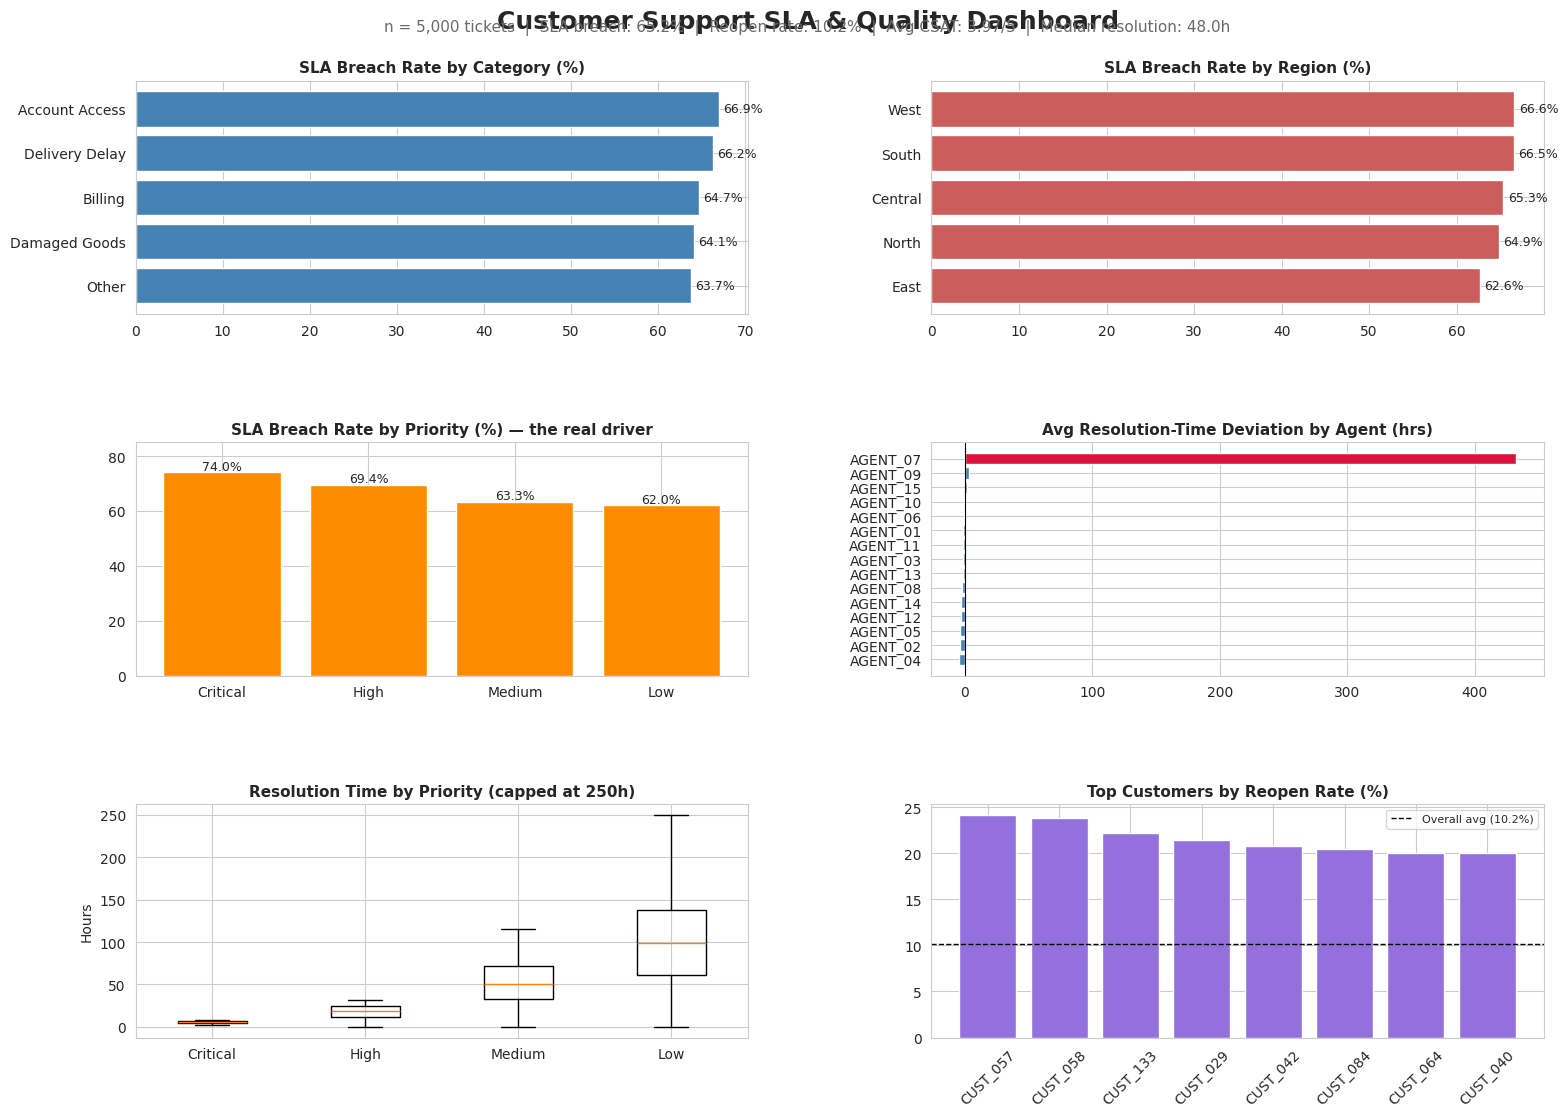

In [ ]:
# ================= Combined Dashboard (one image, all charts) =================
priority_order = ["Critical", "High", "Medium", "Low"]

cat_breach   = df_clean.groupby("category")["sla_breached"].apply(lambda x: (x=="Yes").mean()*100).sort_values()
reg_breach   = df_clean.groupby("region")["sla_breached"].apply(lambda x: (x=="Yes").mean()*100).sort_values()
pri_breach   = df_clean.groupby("priority")["sla_breached"].apply(lambda x: (x=="Yes").mean()*100).reindex(priority_order)

med_by_priority = df_clean.groupby("priority")["resolution_time_clean"].median().reindex(priority_order)
df_clean["expected_"]  = df_clean["priority"].map(med_by_priority)
df_clean["deviation_"] = df_clean["resolution_time_clean"] - df_clean["expected_"]
agent_dev_sorted = df_clean.groupby("agent_id")["deviation_"].mean().sort_values()

cust = df_clean.groupby("customer_id").agg(total=("ticket_id","count"), reopened=("status", lambda x:(x=="Reopened").sum()))
cust["reopen_rate_pct"] = cust.reopened / cust.total * 100
top_reopen = cust.sort_values("reopen_rate_pct", ascending=False).head(8)["reopen_rate_pct"]

overall_reopen = (df_clean.status == "Reopened").mean() * 100
overall_breach = (df_clean.sla_breached == "Yes").mean() * 100
overall_csat   = df_clean.csat_score.mean()
overall_median = df_clean.resolution_time_clean.median()

fig = plt.figure(figsize=(16, 11))
fig.suptitle("Customer Support SLA & Quality Dashboard", fontsize=18, fontweight="bold", y=0.985)
fig.text(0.5, 0.965,
    f"n = {len(df_clean):,} tickets  |  SLA breach: {overall_breach:.1f}%  |  "
    f"Reopen rate: {overall_reopen:.1f}%  |  Avg CSAT: {overall_csat:.2f}/5  |  "
    f"Median resolution: {overall_median:.1f}h",
    ha="center", fontsize=11, color="dimgray")

gs = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.3, top=0.92, bottom=0.05, left=0.08, right=0.96)

ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(cat_breach.index, cat_breach.values, color="steelblue")
ax1.set_title("SLA Breach Rate by Category (%)", fontsize=11, fontweight="bold")
for i, v in enumerate(cat_breach.values):
    ax1.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(reg_breach.index, reg_breach.values, color="indianred")
ax2.set_title("SLA Breach Rate by Region (%)", fontsize=11, fontweight="bold")
for i, v in enumerate(reg_breach.values):
    ax2.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.bar(pri_breach.index, pri_breach.values, color="darkorange")
ax3.set_title("SLA Breach Rate by Priority (%) — the real driver", fontsize=11, fontweight="bold")
for b, v in zip(bars, pri_breach.values):
    ax3.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
ax3.set_ylim(0, 85)

ax4 = fig.add_subplot(gs[1, 1])
colors = ["crimson" if v > 50 else "steelblue" for v in agent_dev_sorted.values]
ax4.barh(agent_dev_sorted.index, agent_dev_sorted.values, color=colors)
ax4.set_title("Avg Resolution-Time Deviation by Agent (hrs)", fontsize=11, fontweight="bold")
ax4.axvline(0, color="black", linewidth=0.8)

ax5 = fig.add_subplot(gs[2, 0])
box_data = [df_clean[df_clean.priority == p]["resolution_time_clean"].dropna().clip(upper=250) for p in priority_order]
ax5.boxplot(box_data, tick_labels=priority_order, showfliers=False)
ax5.set_title("Resolution Time by Priority (capped at 250h)", fontsize=11, fontweight="bold")
ax5.set_ylabel("Hours")

ax6 = fig.add_subplot(gs[2, 1])
ax6.bar(top_reopen.index, top_reopen.values, color="mediumpurple")
ax6.axhline(overall_reopen, color="black", linestyle="--", linewidth=1, label=f"Overall avg ({overall_reopen:.1f}%)")
ax6.set_title("Top Customers by Reopen Rate (%)", fontsize=11, fontweight="bold")
ax6.tick_params(axis="x", rotation=45)
ax6.legend(fontsize=8)

fig.savefig("dashboard.png", dpi=200, bbox_inches="tight")
print("Saved dashboard.png — download it from the folder icon on the left sidebar.")
plt.show()